#Estimar anticipadamente cuántas personas que diligencian el formulario terminarán pagando. Clasificacion

1. Preparación de Datos
2. Validacion cruzada
3. Aprendizaje del Modelo
4. Evaluación del Modelo: matriz de confusion, P,R, ROC
5. Guardar el modelo

* El despliegue se realiza en otro jupyter_notebook

1. Preparación de Datos

In [ ]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

In [ ]:
#Cargamos los datos
data = pd.read_excel("Admisiones_Posgrado_salud.xlsx", sheet_name="Datos")
data.head()

,Periodo,Programa Admision,Presentan examen,Fecha Registro Admision,Estado Pago,Genero,Edad,Pais Nacimiento,Tipo Documento,Departamento Nacimiento,Ciudad Residencia,Naturaleza Origen Universidad
0,202142,Esp en Psiquiatria-Med,SI,2020-10-05 07:45:21,Pago de admision,M,41,Colombia,CC,Santander-CO,ENVIGADO - ANTIOQUIA,Publica
1,202142,Esp Medicina Interna-Med,SI,2020-08-31 08:03:03,Pago de admision,M,35,Colombia,CC,Antioquia-CO,ENVIGADO - ANTIOQUIA,Privada
2,202142,Esp Med Dol y Cui Pal-Med,SI,2020-10-02 08:10:40,Pago de admision,M,43,Colombia,CC,Norte Santander-CO,SABANETA - ANTIOQUIA,Privada
3,202142,Esp Dermatologia-Med,SI,2020-10-06 11:38:21,Pago de admision,M,36,Colombia,CC,Antioquia-CO,ENVIGADO - ANTIOQUIA,Publica
4,202142,Esp Radiologia e Imag Diag-Med,SI,2020-09-11 09:01:34,Pago de admision,M,35,Colombia,CC,Antioquia-CO,MEDELLIN - ANTIOQUIA,Privada


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9188 entries, 0 to 9187
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Periodo                        9188 non-null   int64         
 1   Programa Admision              9188 non-null   object        
 2   Presentan examen               9188 non-null   object        
 3   Fecha Registro Admision        9188 non-null   datetime64[ns]
 4   Estado Pago                    9188 non-null   object        
 5   Genero                         9188 non-null   object        
 6   Edad                           9188 non-null   int64         
 7   Pais Nacimiento                9188 non-null   object        
 8   Tipo Documento                 9188 non-null   object        
 9   Departamento Nacimiento        9188 non-null   object        
 10  Ciudad Residencia              9188 non-null   object        
 11  Naturaleza Origen

In [ ]:
#Corrección tipos de datos
data['Programa Admision']=data['Programa Admision'].astype('category')
data['Periodo']=data['Periodo'].astype('category')
data['Presentan examen']=data['Presentan examen'].astype('category')
data['Estado Pago']=data['Estado Pago'].astype('category')
data['Genero']=data['Genero'].astype('category')
data['Pais Nacimiento']=data['Pais Nacimiento'].astype('category')
data['Tipo Documento']=data['Tipo Documento'].astype('category')
data['Departamento Nacimiento']=data['Departamento Nacimiento'].astype('category')
data['Naturaleza Origen Universidad']=data['Naturaleza Origen Universidad'].astype('category')
data['Ciudad Residencia']=data['Ciudad Residencia'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9188 entries, 0 to 9187
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Periodo                        9188 non-null   category      
 1   Programa Admision              9188 non-null   category      
 2   Presentan examen               9188 non-null   category      
 3   Fecha Registro Admision        9188 non-null   datetime64[ns]
 4   Estado Pago                    9188 non-null   category      
 5   Genero                         9188 non-null   category      
 6   Edad                           9188 non-null   int64         
 7   Pais Nacimiento                9188 non-null   category      
 8   Tipo Documento                 9188 non-null   category      
 9   Departamento Nacimiento        9188 non-null   category      
 10  Ciudad Residencia              9188 non-null   category      
 11  Naturaleza Origen

In [ ]:
# Instalar pandas profiling

!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.8 MB/s eta 0:00:00


In [ ]:
# Cargar librería para Profiling
from pandas_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=False) # minimal=True
profile_data

/tmp/ipykernel_5092/2390340134.py:2: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 45.94it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<Axes: xlabel='Estado Pago'>

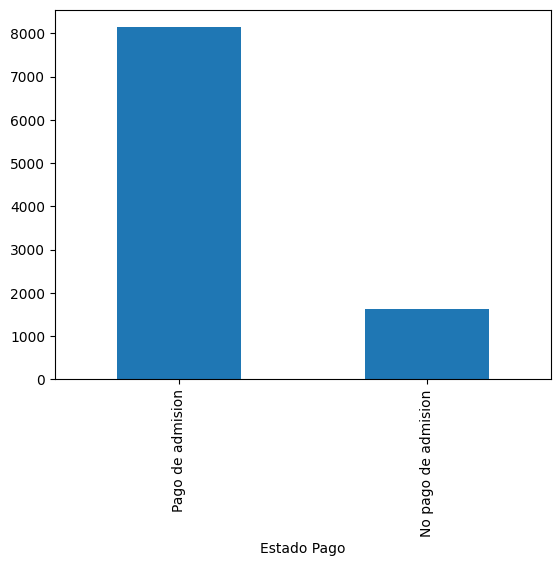

In [ ]:
# La clase minoritaria tendrá el 20% del tamaño de la clase mayoritaria, adicionando datos sintéticos
from imblearn.over_sampling import SMOTE, SMOTENC

# SMOTE: todas las variables predictoras numéricas
# SMOTENC: al menos una predictora categórica

X = data.drop("Estado Pago", axis = 1)
Y = data['Estado Pago']

# Drop 'Fecha Registro Admision' column as SMOTENC does not handle datetime objects.
# Alternatively, it could be converted to a numerical representation if its temporal information is important.
X = X.drop('Fecha Registro Admision', axis=1)

# Identify the indices of categorical features in the modified X
# X columns after dropping 'Fecha Registro Admision':
# 0: Periodo (category)
# 1: Programa Admision (category)
# 2: Presentan examen (category)
# 3: Genero (category)
# 4: Edad (int64) - Numerical
# 5: Pais Nacimiento (category)
# 6: Tipo Documento (category)
# 7: Departamento Nacimiento (category)
# 8: Ciudad Residencia (category)
# 9: Naturaleza Origen Universidad (category)

# The categorical features are at indices: 0, 1, 2, 3, 5, 6, 7, 8, 9
# 'Edad' (index 4) is numerical and should not be in categorical_features.
categorical_features_indices = [0, 1, 2, 3, 5, 6, 7, 8, 9]

# Cambiamos sampling_strategy a 0.2 para que sea el 20%
smote = SMOTENC(k_neighbors=2, sampling_strategy=0.2, categorical_features=categorical_features_indices)
X_smote, y_smote = smote.fit_resample(X,Y)

# Creamos un dataframe con los resultados (X_smote, y_smote)
data = pd.DataFrame(columns=X_smote.columns.values, data=X_smote)
data['Estado Pago']=y_smote
data['Estado Pago'].value_counts().plot(kind='bar')

In [ ]:
#LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data["Estado Pago"]=labelencoder.fit_transform(data["Estado Pago"])
data.head()

,Periodo,Programa Admision,Presentan examen,Genero,Edad,Pais Nacimiento,Tipo Documento,Departamento Nacimiento,Ciudad Residencia,Naturaleza Origen Universidad,Estado Pago
0,202142,Esp en Psiquiatria-Med,SI,M,41,Colombia,CC,Santander-CO,ENVIGADO - ANTIOQUIA,Publica,1
1,202142,Esp Medicina Interna-Med,SI,M,35,Colombia,CC,Antioquia-CO,ENVIGADO - ANTIOQUIA,Privada,1
2,202142,Esp Med Dol y Cui Pal-Med,SI,M,43,Colombia,CC,Norte Santander-CO,SABANETA - ANTIOQUIA,Privada,1
3,202142,Esp Dermatologia-Med,SI,M,36,Colombia,CC,Antioquia-CO,ENVIGADO - ANTIOQUIA,Publica,1
4,202142,Esp Radiologia e Imag Diag-Med,SI,M,35,Colombia,CC,Antioquia-CO,MEDELLIN - ANTIOQUIA,Privada,1


# 2. Validación Cruzada







In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# 1. Definir las variables predictoras (X) basándonos exactamente en las columnas disponibles
features = [
    'Periodo',
    'Programa Admision',
    'Presentan examen',
    'Genero',
    'Edad',
    'Pais Nacimiento',
    'Tipo Documento',
    'Departamento Nacimiento',
    'Ciudad Residencia',
    'Naturaleza Origen Universidad'
]

X = data[features]
y = data['Estado Pago']

# 2. Convertir las variables categóricas a variables dummy (One-Hot Encoding)
# Nota: 'Edad' es numérica (int64), pd.get_dummies la mantendrá intacta.
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Configurar el modelo con los hiperparámetros de la imagen anterior
arbol_clf = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=42)

# 4. Configurar la validación cruzada (por ejemplo, 5 o 10 particiones/folds)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 5. Ejecutar la validación cruzada y obtener las métricas de precisión (accuracy)
scores = cross_val_score(arbol_clf, X_encoded, y, cv=cv, scoring='accuracy')

print(f"Precisión en cada partición (Folds): {scores}")
print(f"Precisión promedio: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

Precisión en cada partición (Folds): [0.8444217  0.83000512 0.83307732 0.83358935 0.85099846]
Precisión promedio: 0.8384 (+/- 0.0159)


# TREE

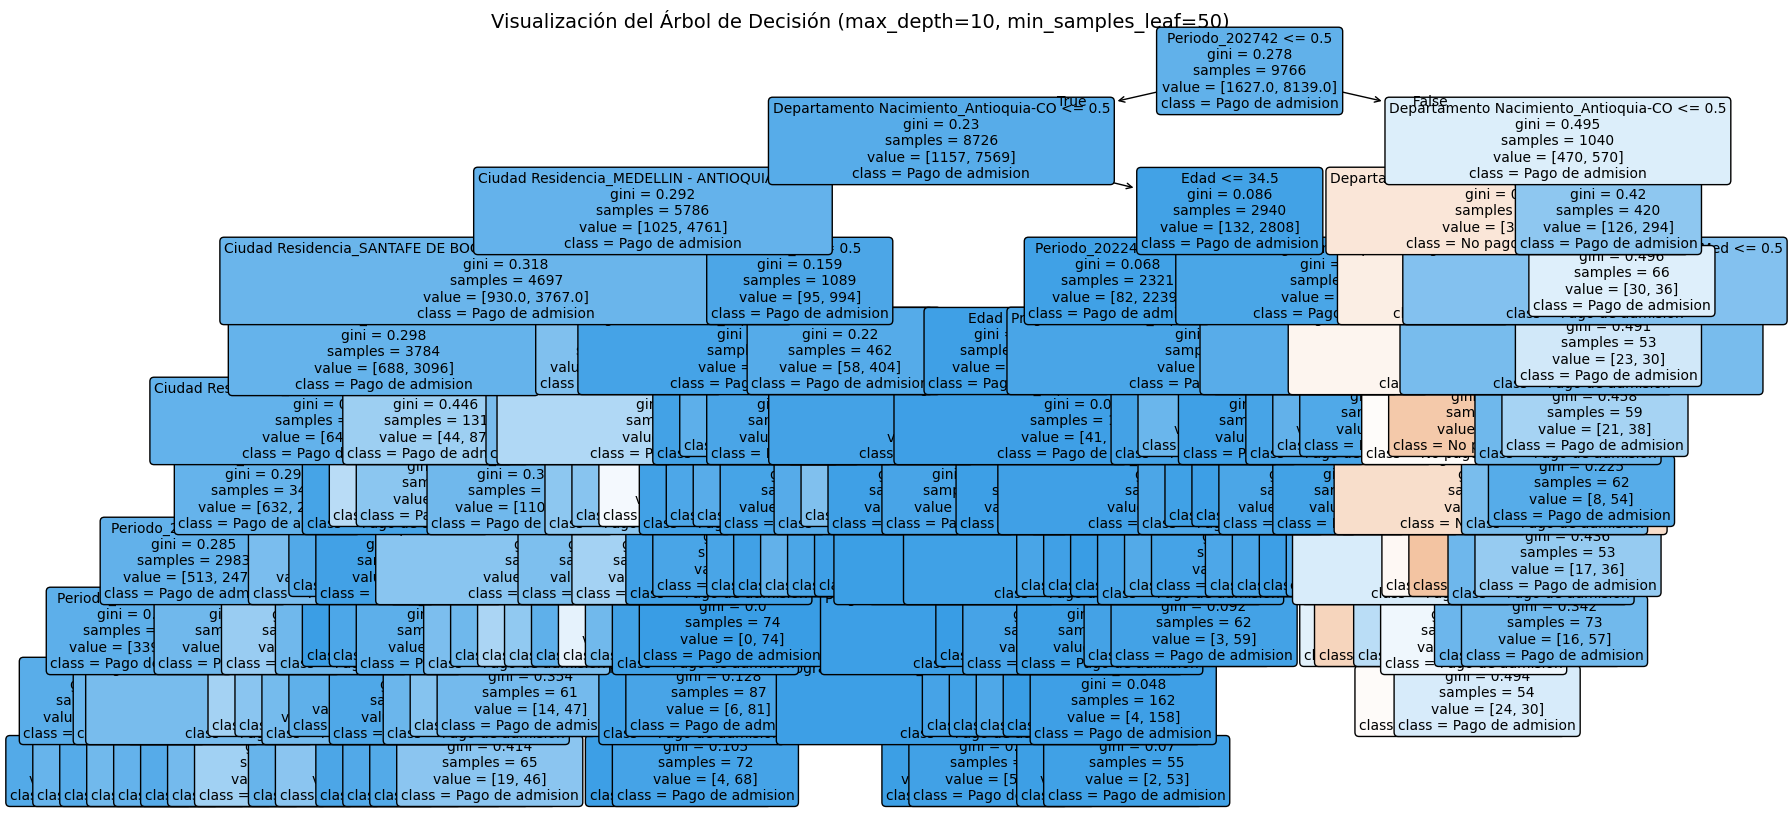

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configurar el tamaño de la figura para que el árbol sea legible
plt.figure(figsize=(20, 10))

# Fit the model to get the 'classes_' attribute before plotting
arbol_clf.fit(X_encoded, y)

# Generar el gráfico del árbol de decisión
plot_tree(
    arbol_clf,
    feature_names=X_encoded.columns.tolist(), # Nombres de las variables predictoras procesadas
    class_names=[str(c) for c in labelencoder.classes_], # Clases de la variable objetivo (Estado Pago) from labelencoder
    filled=True,          # Rellenar con colores para diferenciar las clases
    rounded=True,         # Esquinas redondeadas en los nodos
    fontsize=10           # Tamaño de la letra
)

# Mostrar el gráfico
plt.title("Visualización del Árbol de Decisión (max_depth=10, min_samples_leaf=50)", fontsize=14)
plt.show()

In [ ]:
#Tree
from sklearn import tree
from sklearn.model_selection import cross_validate # Import cross_validate

modelTree = tree.DecisionTreeClassifier(criterion='gini', min_samples_leaf=50, max_depth=10)

# Define scoring parameter
scoring = 'accuracy'

# Use X_encoded for cross-validation as it contains numerical features
scores = cross_validate(modelTree, X_encoded, y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_score,train_score
0,0.089956,0.005487,0.844422,0.840886
1,0.085258,0.005309,0.830005,0.843594
2,0.089828,0.005476,0.833077,0.843210
3,0.097752,0.005342,0.833589,0.843466
4,0.086933,0.005246,0.850998,0.841034


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

#Cuidado overfitting, más de 5 puntos de diferencia

,0
fit_time,0.089945
score_time,0.005372
test_score,0.838418
train_score,0.842438


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV = pd.DataFrame() # Initialize comparacion_CV DataFrame
comparacion_CV['Tree']=scores['test_score'] # Use 'test_score' as 'f1_macro' was not calculated
comparacion_CV

,Tree
0,0.844422
1,0.830005
2,0.833077
3,0.833589
4,0.850998


# RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=200,  max_samples=0.9, criterion='gini',
                              max_depth=20, min_samples_leaf=10)

# Usamos X_encoded en lugar de X para que todas las características sean numéricas
scores = cross_validate(model_rf, X_encoded, y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_score,train_score
0,1.330306,0.043656,0.836233,0.832693
1,1.777395,0.062080,0.826421,0.835147
2,1.910463,0.042813,0.829493,0.834379
3,1.303010,0.041678,0.828469,0.834635
4,1.337103,0.041690,0.846390,0.830155


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,1.531655
score_time,0.046383
test_score,0.833401
train_score,0.833402


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['RF']=scores['test_score']
comparacion_CV

,Tree,RF
0,0.844422,0.836233
1,0.830005,0.826421
2,0.833077,0.829493
3,0.833589,0.828469
4,0.850998,0.846390


# SVM

In [ ]:
#SVM
from sklearn.svm import SVC # SVR
model_svm=SVC(kernel='rbf', C=5)

# Usamos X_encoded en lugar de X para que todas las características sean numéricas
scores = cross_validate(model_svm, X_encoded, y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_score,train_score
0,11.472363,2.551960,0.836233,0.832693
1,9.684446,3.222206,0.826421,0.835147
2,9.739549,3.757174,0.829493,0.834379
3,10.398653,3.806841,0.828469,0.834635
4,9.880688,3.277633,0.846390,0.830155


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,10.235140
score_time,3.323163
test_score,0.833401
train_score,0.833402


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['SVM']=scores['test_score']
comparacion_CV

,Tree,RF,SVM
0,0.844422,0.836233,0.836233
1,0.830005,0.826421,0.826421
2,0.833077,0.829493,0.829493
3,0.833589,0.828469,0.828469
4,0.850998,0.846390,0.846390


# NN

In [ ]:
from sklearn.neural_network import MLPClassifier
model_rn = MLPClassifier(activation="logistic",hidden_layer_sizes=(50), learning_rate='constant',
                     learning_rate_init=0.02, momentum= 0.03, max_iter=500, random_state=3)

# Usamos X_encoded en lugar de X para que todas las características sean numéricas
scores = cross_validate(model_rn, X_encoded, y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores

,fit_time,score_time,test_score,train_score
0,21.754789,0.017840,0.842886,0.956861
1,30.569195,0.018734,0.796211,0.963778
2,21.944102,0.018868,0.802867,0.956355
3,15.379334,0.018486,0.827957,0.943044
4,25.859133,0.016867,0.829493,0.960323


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
scores.mean()

,0
fit_time,23.101310
score_time,0.018159
test_score,0.819883
train_score,0.956072


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['NN']=scores['test_score']
comparacion_CV

,Tree,RF,SVM,NN
0,0.844422,0.836233,0.836233,0.842886
1,0.830005,0.826421,0.826421,0.796211
2,0.833077,0.829493,0.829493,0.802867
3,0.833589,0.828469,0.828469,0.827957
4,0.850998,0.846390,0.846390,0.829493


# 3. Selección del Modelo

In [ ]:
comparacion_CV

,Tree,RF,SVM,NN
0,0.844422,0.836233,0.836233,0.842886
1,0.830005,0.826421,0.826421,0.796211
2,0.833077,0.829493,0.829493,0.802867
3,0.833589,0.828469,0.828469,0.827957
4,0.850998,0.846390,0.846390,0.829493


<Axes: >

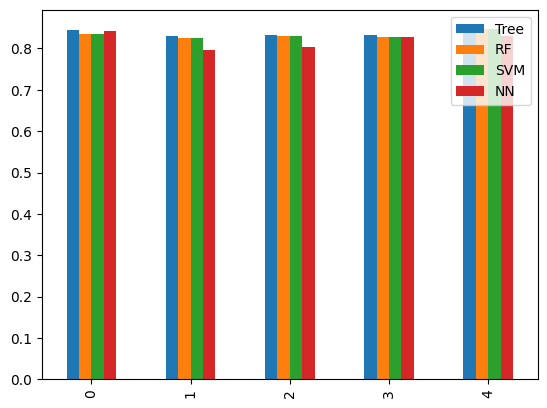

In [ ]:
#Resultados de la validación cruzada
comparacion_CV.plot(kind='bar')

# 4. Modelo final con todos los datos

In [ ]:
#Modelo final
model_rf.fit(X_encoded, y) # Usamos X_encoded para el entrenamiento final

RandomForestClassifier(max_depth=20, max_samples=0.9, min_samples_leaf=10,
                       n_estimators=200)

In [ ]:
#Se guarda el modelo
import pickle
filename = 'modelo-cla.pkl'
variables=X.columns._values
pickle.dump([model_rf,labelencoder,variables], open(filename, 'wb'))